# Regressione Random Forest

Proseguendo il percorso di questo progetto, l'obiettivo di questo notebook è allenare un modello capace di compiere previsioni sul valore delle concentrazioni di vari inquinanti nell'aria su base oraria e giornaliera. Tuttavia, al contrario di quanto avvenuto per la classificazione, vogliamo estrarre predizioni quantitative e non qualitative. Per farlo usiamo un algoritmo del tipo Random Forest Regressor.

Questo algoritmo crea una foresta di alberi decisionali le cui foglie non corrispondono più a classi ma a valori numerici, pertanto, la predizione non corrisponde più alla classe predetta dalla maggioranza degli alberi ma alla media delle predizioni numeriche di tutti gli alberi.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.regr_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 58327419

# Modelli orari

Come negli altri notebook, cominciamo cercando di compiere predizioni per l'ora successiva. Questo chiaramente ha un'utilità pratica minore nella maggior parte dei casi ma ci permette di lavorare con molti più dati e, pertanto, ci aspettiamo predizioni più accurate e precise.

## PM10

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM10_df = pd.read_csv('../../data/processed/dataset_hour_PM10_processed.csv')
hour_PM10_df.dropna(inplace=True)

In [4]:
hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


### Modello

Seguiamo la stessa frequenza di operazioni usata molte volte in precedenza: alleniamo il modello su un insieme di train (80%) ottenendo anche i valori ottimali per gli iperparametri e, successivamente, valutiamo la performance del modello attraverso l'insieme di test (20%). Questa procedura sarà ripetuta per ciascun inquinante. In seguito ripeteremo la stessa operazione ma con una formulazione su base giornaliera.

In [5]:
# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# griglia degli iperparametri, inizialmente abbiamo operato un GridSearchCV su tutta la griglia ma dato il lungo tempo richiesto per questa operazione, 
# (più di 30 min) scegliamo di utilizzare solo la combinazione migliore per tutti gli allenamenti successivi. Riportiamo qui la griglia originale:
#param_grid_rfr = {'n_estimators': [100, 200, 500],                   # numero di alberi
#                    'max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM10_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # vogliamo minimizzare l'RMSE, quindi massimizziamo il suo opposto
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [6]:
# splittiamo il dataset
feature_cols = hour_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_h_X_train, PM10_h_X_test, PM10_h_y_train, PM10_h_y_test = fs.get_train_test(hour_PM10_df, 0.8, feature_cols)

### Allenamento modello

In [7]:
# training
rfr_PM10_h.fit(PM10_h_X_train, PM10_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [8]:
print('Best score:')
print(rfr_PM10_h.best_score_)
# miglior modello
best_rfr_PM10_h = rfr_PM10_h.best_estimator_

Best score:
-6.259306427692394


### Studio importanza features

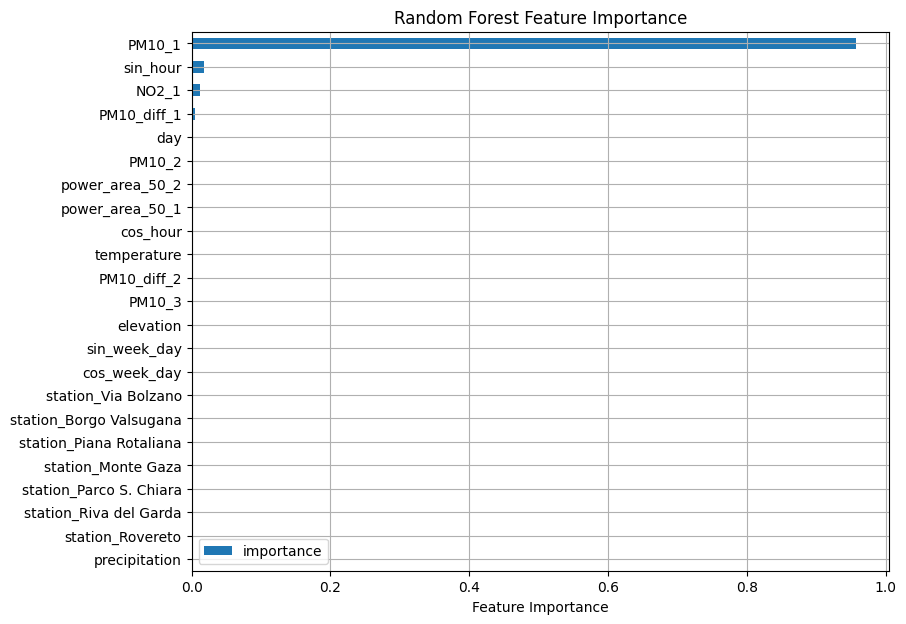

In [9]:
fs.display_importances(best_rfr_PM10_h, feature_cols)

Vediamo che la feature di gran lunga più rilevante è la concentrazione di PM10 nell'ora precedente, il che non ci stupisce essendo questa la feature più logicamente collegata al nostro target. Appare interessante che, per quanto molto meno rilevante, la seconda feature più importante sia collegata all'orario.

### Valutazione performance

In [10]:
full_PM10_h_tr = PM10_h_X_train.copy()
full_PM10_h_tr['actual'] = PM10_h_y_train
full_PM10_h_tr['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_train)

full_PM10_h_te = PM10_h_X_test.copy()
full_PM10_h_te['actual'] = PM10_h_y_test
full_PM10_h_te['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM10_h_tr['actual'], full_PM10_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM10_h_te['actual'], full_PM10_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          33.64127780148836
Root Mean Squared Error (RMSE):    5.800110154254689
Mean Absolute Error (MAE):         3.0769183908026774
Coefficient of Determination (R2): 0.9057775546964977
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          33.954642034128774
Root Mean Squared Error (RMSE):    5.8270611833177774
Mean Absolute Error (MAE):         3.7282990954871664
Coefficient of Determination (R2): 0.9383076744152915


Vediamo da questi parametri che il modello funziona relativamente bene. Il valore di $R^2$ superiore a 0.9 è solitamente indice di buone previsioni; tuttavia, poiché trattiamo dati con una importante dipendenza temporale, questo parametro (che fa riferimento alla media del campione) è meno rilevante. Scegliamo quindi di concentrarci maggiormente su RMSE e MAE. Il valore del MAE ci indica che il nostro modello commette mediamente un errore di circa 3.7 $\mu g/m^3$, che, data una deviazione standard dei dati di circa 20 $\mu g/m^3$, appare come un ottimo risultato.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

In [11]:
# aggiungiamo il tempo
full_PM10_h_tr = fs.add_time(full_PM10_h_tr)
full_PM10_h_te = fs.add_time(full_PM10_h_te)

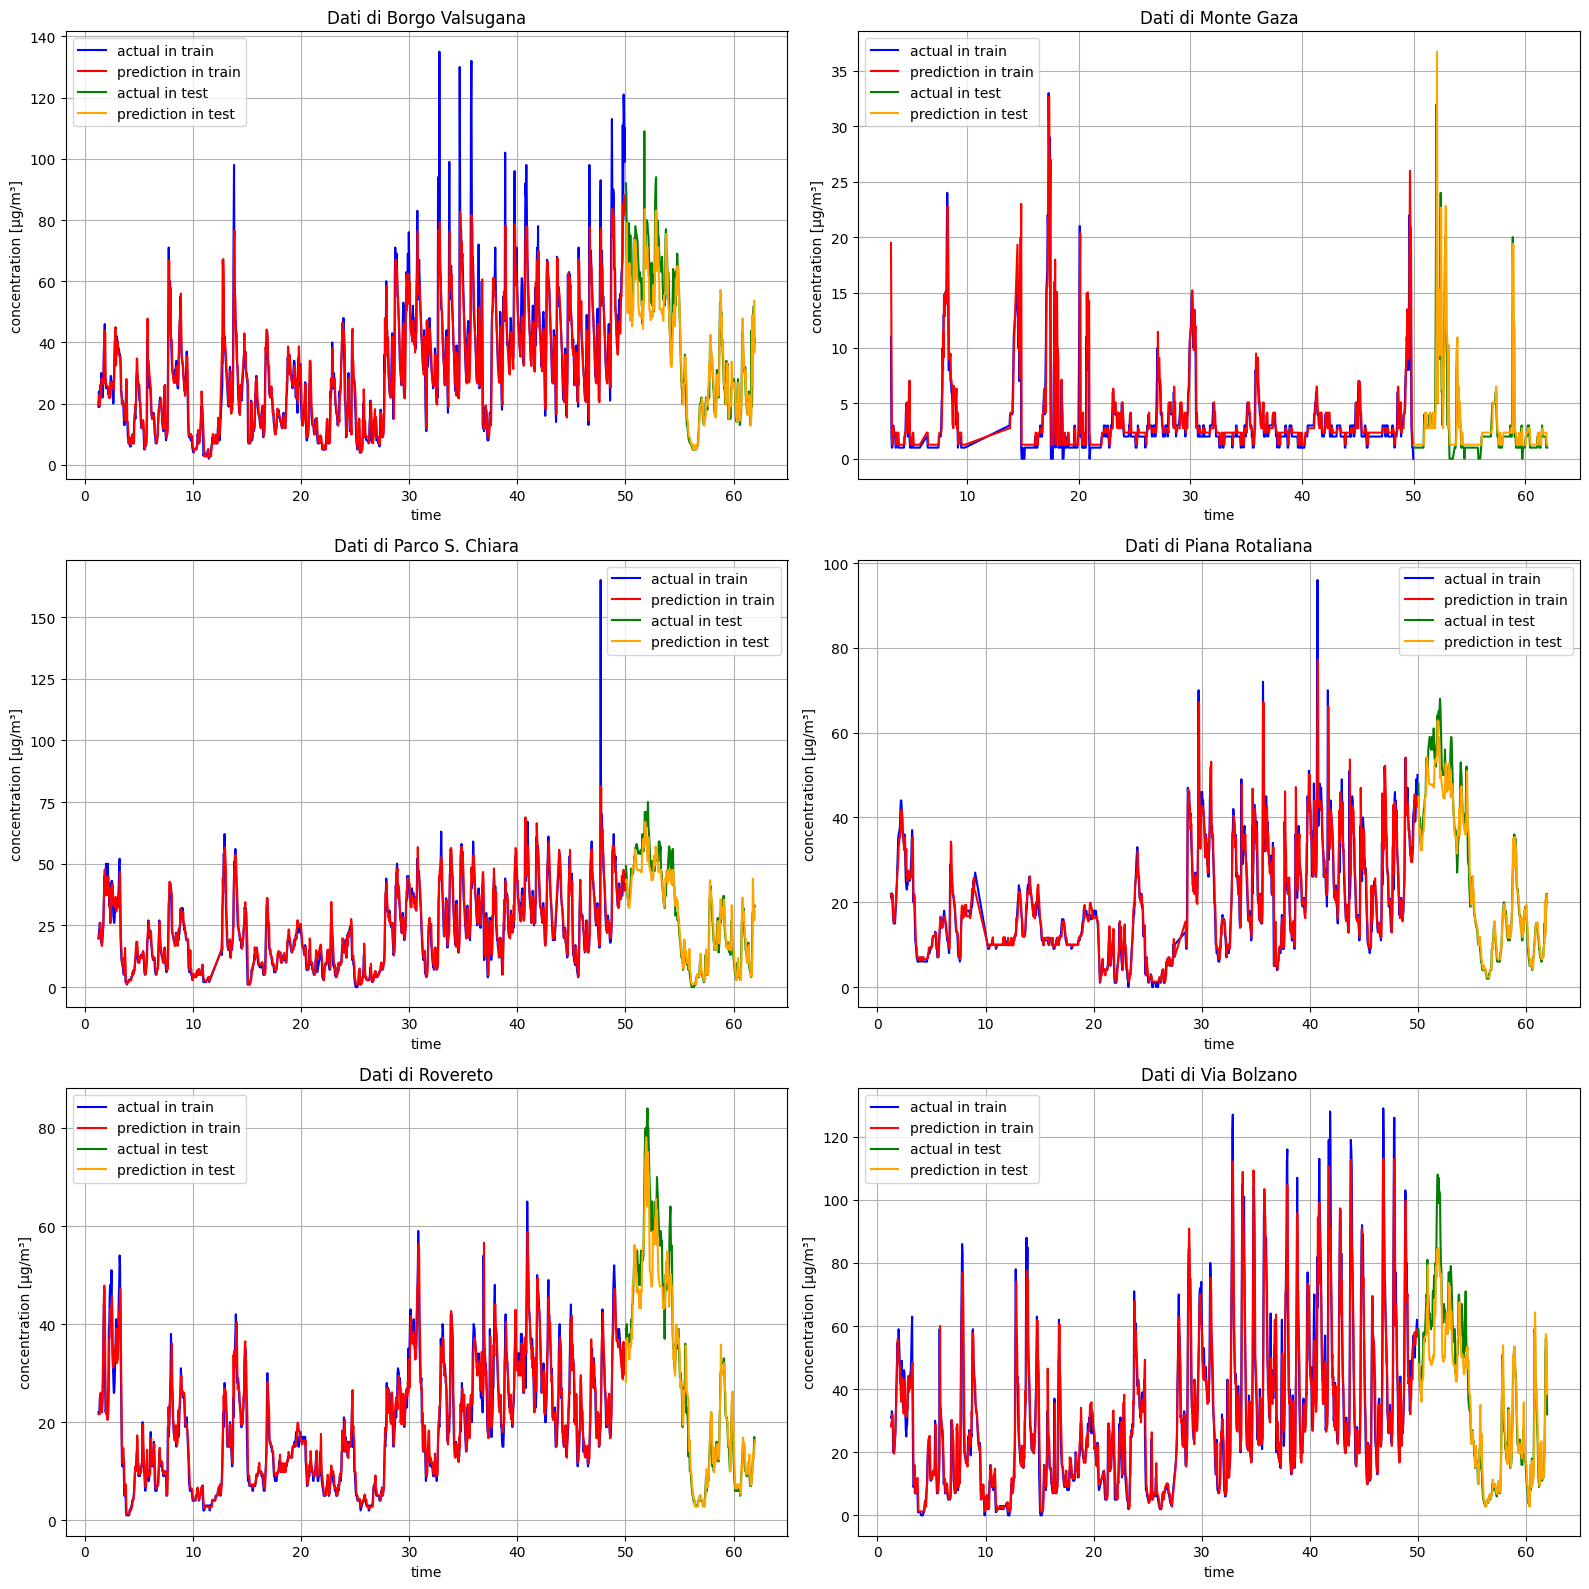

In [12]:
fs.plot_predictions(full_PM10_h_tr, full_PM10_h_te)

I risultati dei grafici appaiono incoraggianti, le previsioni seguono fedelmente i punti reali. Appare chiaro tuttavia che il modello fatica particolarmente in prossimità dei marcati picchi della funzione. Inoltre, data la scala temporale del problema, è difficile che le previsioni del modello si allontanino incredibilmente dai dati reali visto il breve intervallo temporale tra dati e previsione.
In conclusione, a causa della scala, è difficile valutare correttamente il modello usando unicamente i grafici. Scegliamo quindi di confermare il giudizio positivo ottenuto a partire dai parametri indicati sopra.

## PM2.5

In [13]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM25_df = pd.read_csv('../../data/processed/dataset_hour_PM2_5_processed.csv')
hour_PM25_df.dropna(inplace=True)

In [14]:
hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


### Modello

In [15]:
param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM25_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [16]:
# splittiamo il dataset
feature_cols = hour_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_h_X_train, PM25_h_X_test, PM25_h_y_train, PM25_h_y_test = fs.get_train_test(hour_PM25_df, 0.8, feature_cols)

### Allenamento modello

In [17]:
# training
rfr_PM25_h.fit(PM25_h_X_train, PM25_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [18]:
print('Best score:')
print(rfr_PM25_h.best_score_)
# miglior modello
best_rfr_PM25_h = rfr_PM25_h.best_estimator_

Best score:
-5.095299241920562


### Studio importanza features

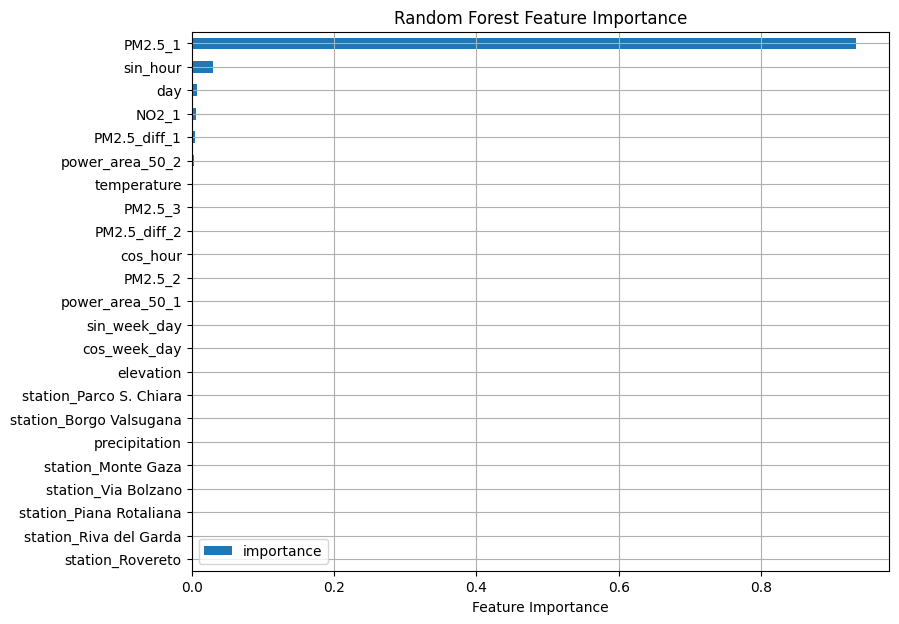

In [19]:
fs.display_importances(best_rfr_PM25_h, feature_cols)

Come prima, vediamo che il modello fa affidamento quasi unicamente alla concentrazione dell'inquinante in questione nell'ora precedente, il che non ci stupisce.

### Valutazione performance

In [20]:
full_PM25_h_tr = PM25_h_X_train.copy()
full_PM25_h_tr['actual'] = PM25_h_y_train
full_PM25_h_tr['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_train)

full_PM25_h_te = PM25_h_X_test.copy()
full_PM25_h_te['actual'] = PM25_h_y_test
full_PM25_h_te['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_h_tr['actual'], full_PM25_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_h_te['actual'], full_PM25_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          18.56178469571398
Root Mean Squared Error (RMSE):    4.308338971774851
Mean Absolute Error (MAE):         2.542595163118802
Coefficient of Determination (R2): 0.8765425273932905
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          25.250080129854886
Root Mean Squared Error (RMSE):    5.024945783772686
Mean Absolute Error (MAE):         3.5878353948530504
Coefficient of Determination (R2): 0.9167812068034984


Vediamo che il modello è buono, con parametri comparabili a quell ottenuti precedentemente.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

In [21]:
# aggiungiamo il tempo
full_PM25_h_tr = fs.add_time(full_PM25_h_tr)
full_PM25_h_te = fs.add_time(full_PM25_h_te)

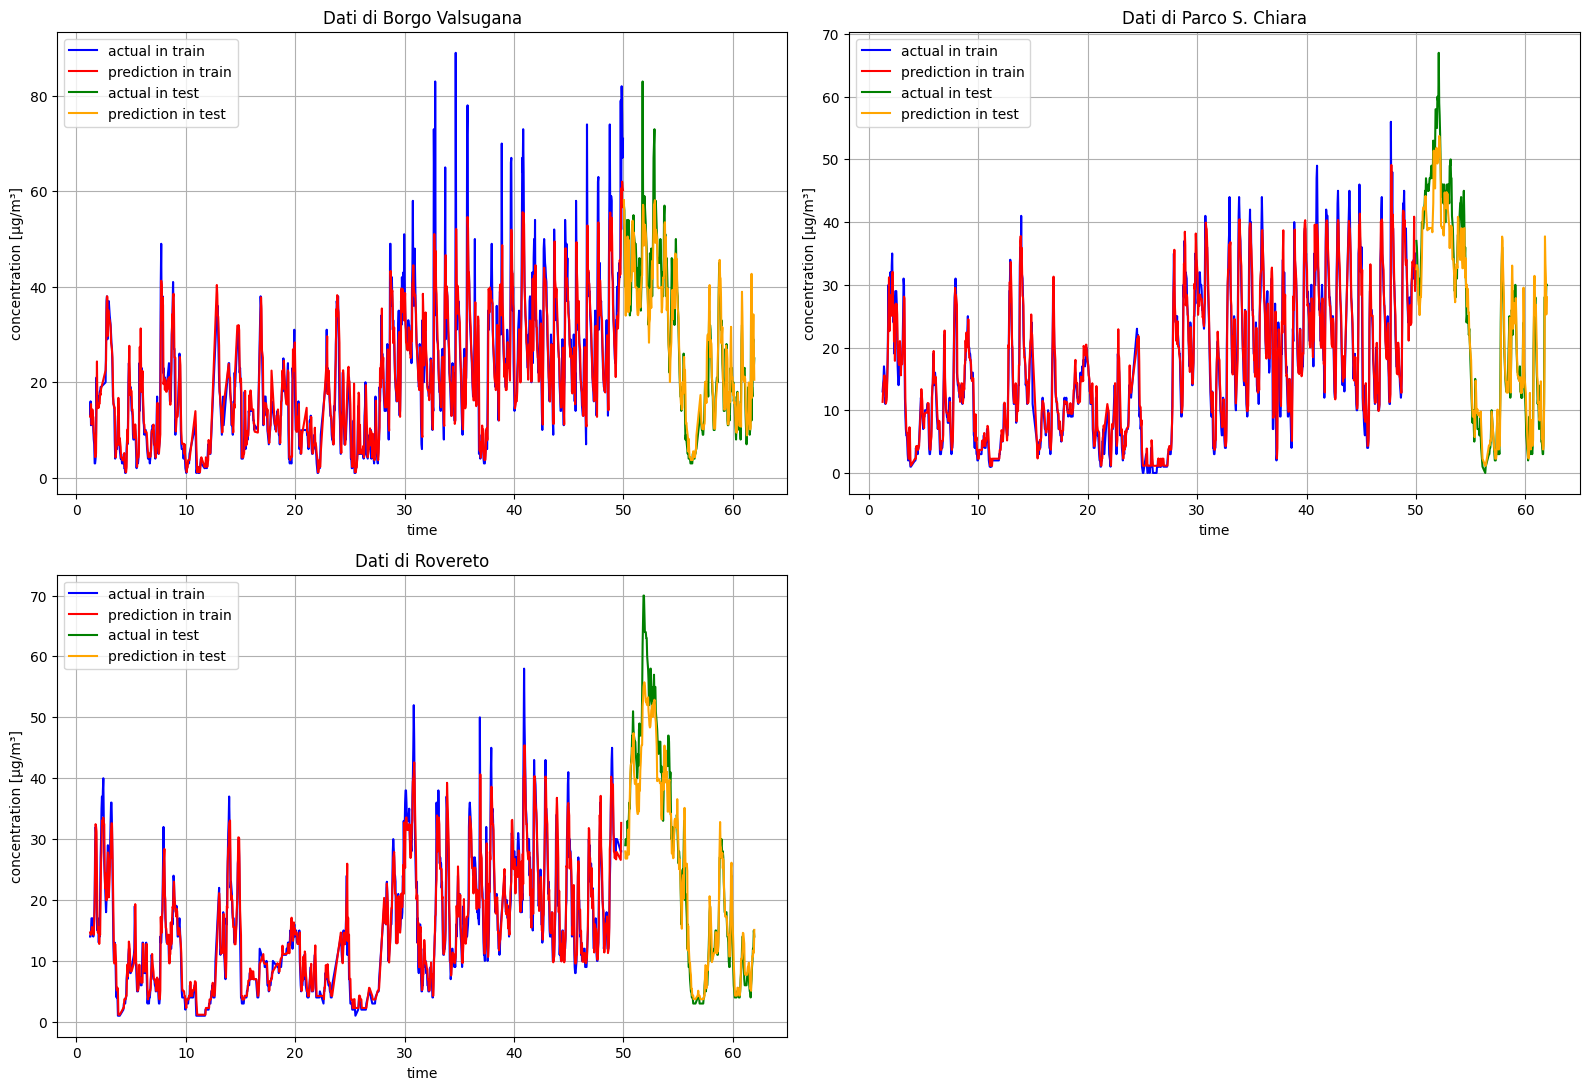

In [22]:
fs.plot_predictions(full_PM25_h_tr, full_PM25_h_te)

Il PM2.5 viene raccolto in meno stazioni, perciò abbiamo meno grafici. In ogni caso, vediamo un comportamento simile a quello visto prima, con previsioni piuttosto buone e un'evidente fatica del modello nelle predizioni dei picchi. Questo è particolarmente vero nell'insieme di test dove, per le stazioni di Parco S. Chiara e Rovereto, la concentrazione di PM2.5 raggiunge un picco assoluto che il modello non roesce a prevedere poiché è la prima volta che si interfaccia con dati di quella scala. Questa è una caratteristica insita nei nostri dati e, pertanto, non è possibile risolverla senza espandere il dataset aggiungendo dati che purtroppo non possediamo. In ogni caso, ci affidiamo ai valori del RMSE e del MAE per confermare la bontà del modello.

## Ozono

In [23]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_O3_df = pd.read_csv('../../data/processed/dataset_hour_O3_processed.csv')
hour_O3_df.dropna(inplace=True)

In [24]:
hour_O3_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,O3_1,O3_2,O3_3,O3_diff_1,O3_diff_2,PM10_1,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,21.0,18.0,16.969367,14.669913,2.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,19.0,16.0,15.329278,16.969367,2.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,24.0,16.0,17.519438,15.329278,2.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,19.0,15.0,17.446178,17.519438,3.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,3.0,2.0,2.0,1.0,1.0,22.0,15.0,17.484408,17.446178,5.0


### Modello

In [25]:
param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_O3_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [26]:
# splittiamo il dataset
feature_cols = hour_O3_df.columns.difference(['target'])

# creiamo train e test
O3_h_X_train, O3_h_X_test, O3_h_y_train, O3_h_y_test = fs.get_train_test(hour_O3_df, 0.8, feature_cols)

### Allenamento modello

In [27]:
# training
rfr_O3_h.fit(O3_h_X_train, O3_h_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [28]:
print('Best score:')
print(rfr_O3_h.best_score_)
# miglior modello
best_rfr_O3_h = rfr_O3_h.best_estimator_

Best score:
-5.930254811660709


### Studio importanza features

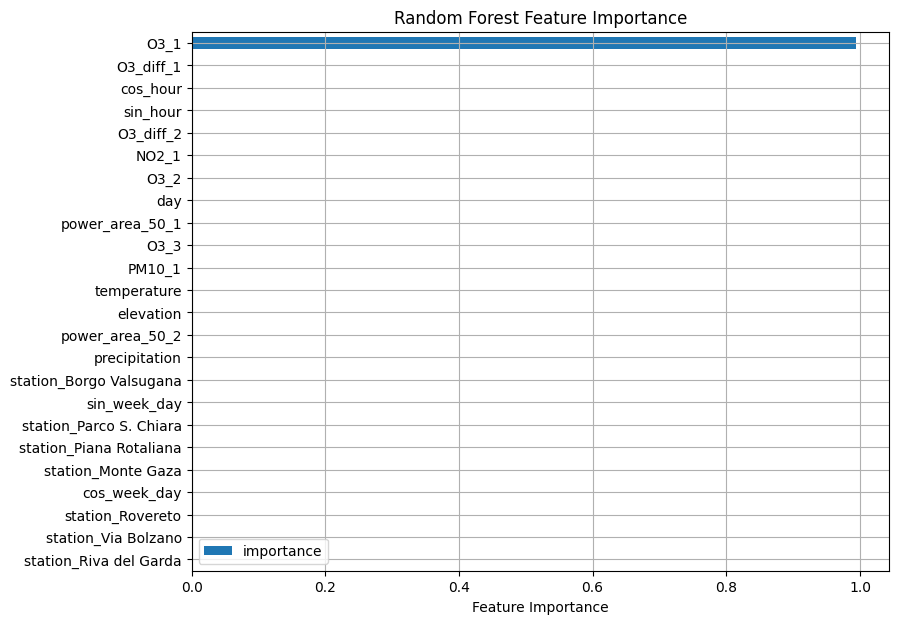

In [29]:
fs.display_importances(best_rfr_O3_h, feature_cols)

La tendenza precedente si ripropone ancora più marcatamente, con la concentrazione di ozono nell'ora precedente che determina essenzialmente totalità delle decisioni del modello.

### Valutazione performance

In [30]:
full_O3_h_tr = O3_h_X_train.copy()
full_O3_h_tr['actual'] = O3_h_y_train
full_O3_h_tr['prediction'] = best_rfr_O3_h.predict(O3_h_X_train)

full_O3_h_te = O3_h_X_test.copy()
full_O3_h_te['actual'] = O3_h_y_test
full_O3_h_te['prediction'] = best_rfr_O3_h.predict(O3_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_h_tr['actual'], full_O3_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_h_te['actual'], full_O3_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          20.98680340286577
Root Mean Squared Error (RMSE):    4.581135601885822
Mean Absolute Error (MAE):         2.7231317208386736
Coefficient of Determination (R2): 0.9749977969269044
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          14.440935500935115
Root Mean Squared Error (RMSE):    3.8001230902347247
Mean Absolute Error (MAE):         2.1974595524560883
Coefficient of Determination (R2): 0.9833185793886366


In questo caso il modello appare particolarmente buono, anche quando comparato con i modelli ottenuti per gli inquinanti precedenti.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

In [31]:
# aggiungiamo il tempo
full_O3_h_tr = fs.add_time(full_O3_h_tr)
full_O3_h_te = fs.add_time(full_O3_h_te)

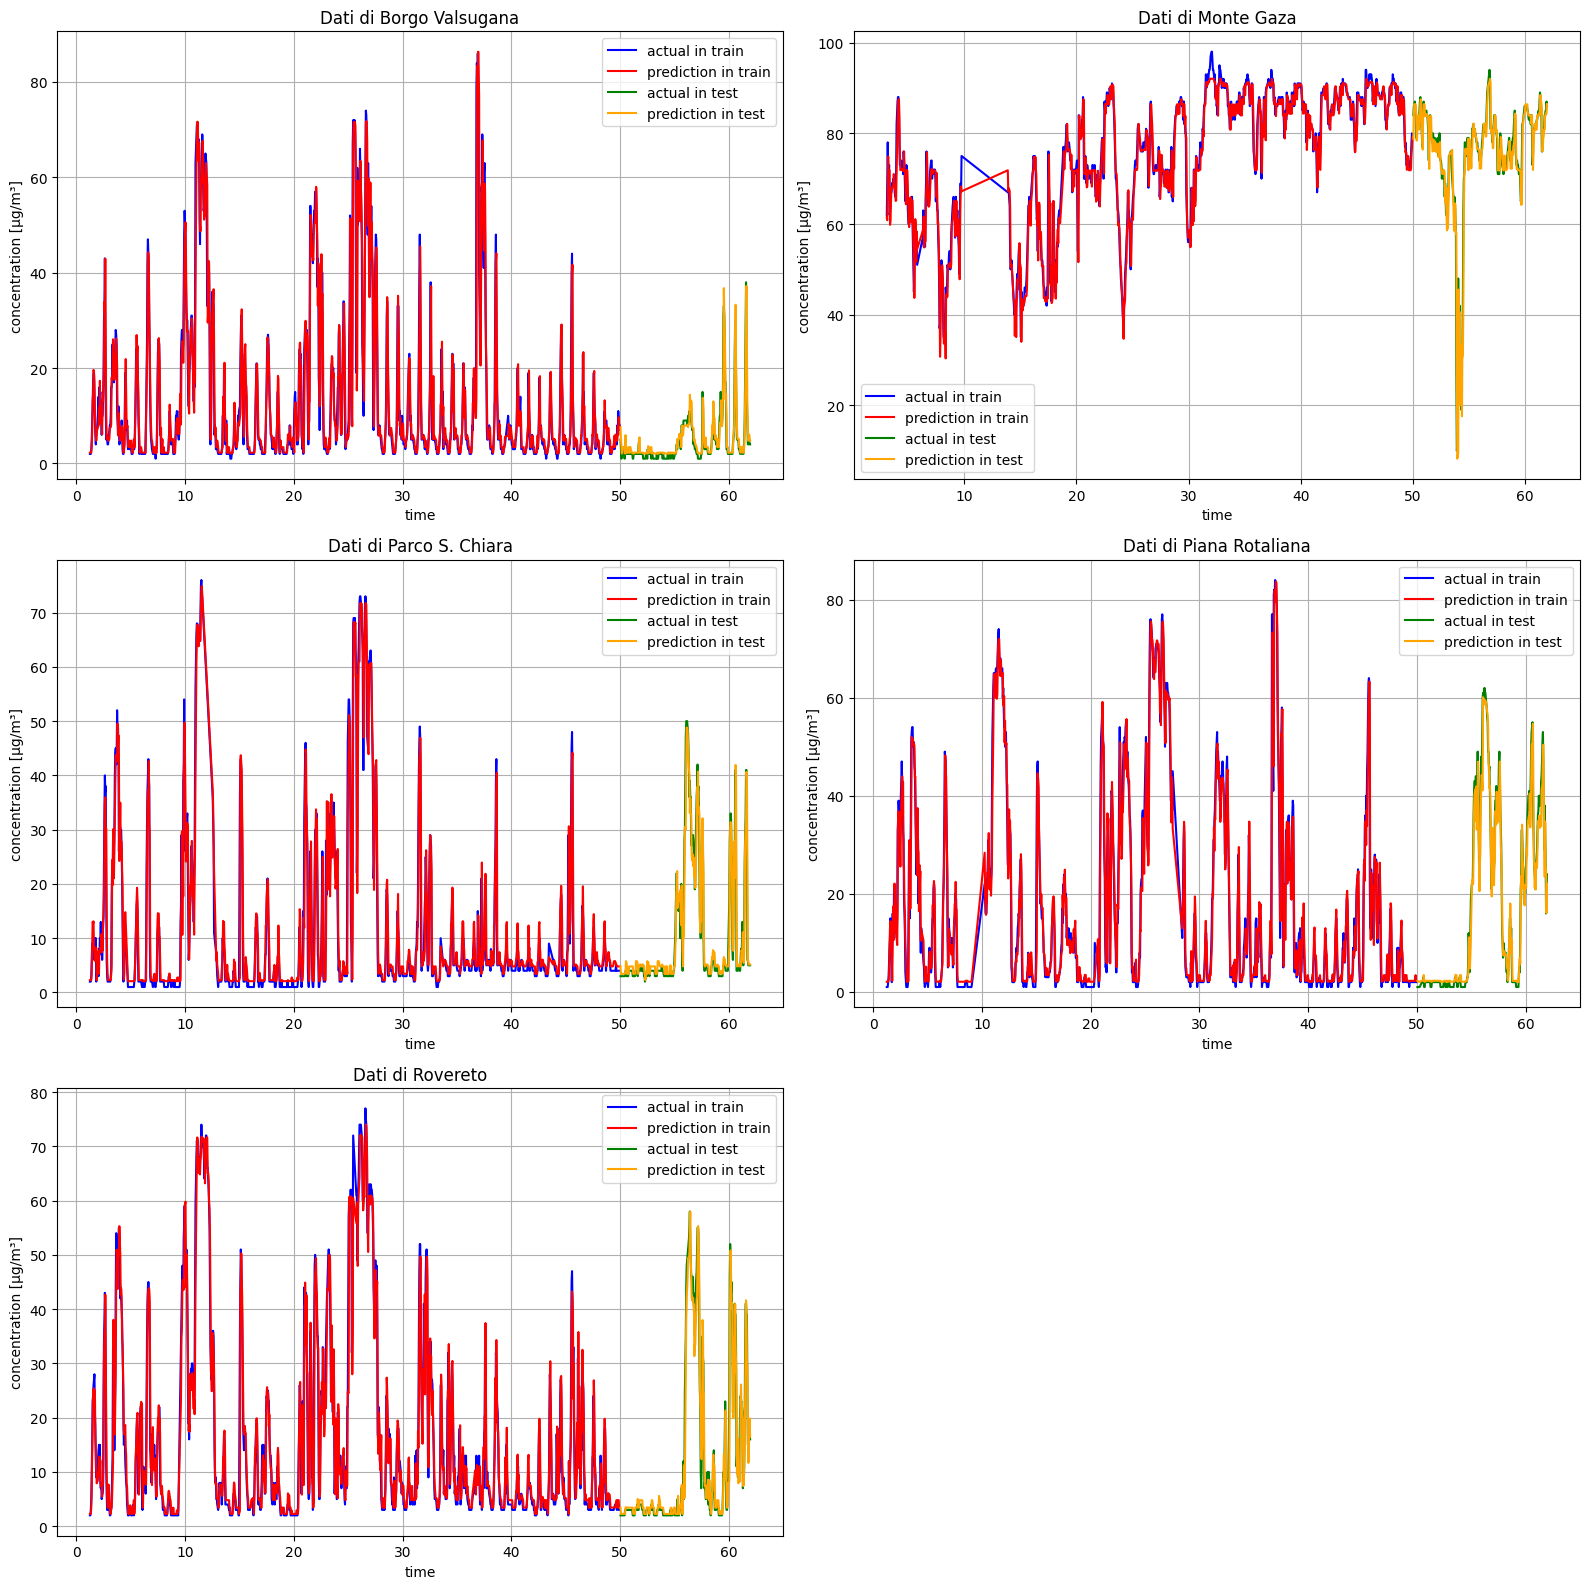

In [32]:
fs.plot_predictions(full_O3_h_tr, full_O3_h_te)

I grafici appaiono confermare la precedente buona valutazione del modello; infatti, i dati presentano picchi meno improvvisi e notiamo che il modello riesce a prevederli più fedelmente rispetto a prima. Consideriamo pertanto questo esercizio come particolarmente riuscito.

# Modelli giornalieri

Ripetiamo ora quanto fatto nella prima parte di questo notebook ma con previsioni su base giornaliera invece che oraria. Come spiegato in notebook precedenti, questo aumenta considerevolmente la difficoltà dell'esercizio poiché riduce drasticamente il numero di dati e aumenta la distanza temporale tra dati e previsione. Per questi motivi, ci aspettiamo risultati peggiori rispetto a quelli ottenuti per i modelli orari.

## PM10

In [33]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')
day_PM10_df.dropna(inplace=True)

In [34]:
day_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM10_1,PM10_2,PM10_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,0,0,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,28.869565,25.739130,3.130435,21.086957,18.197335,23.652174
1,1,0,0,0,0,0,0,410,4,1.000000,0.000000,10.796739,0.126087,23.652174,28.869565,-5.217391,18.826087,17.478475,14.739130
2,1,0,0,0,0,0,0,410,5,0.623490,0.781831,7.609783,0.028261,14.739130,23.652174,-8.913043,26.739130,37.200400,17.000000
3,1,0,0,0,0,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,17.000000,14.739130,2.260870,25.913043,37.421266,14.739130
4,1,0,0,0,0,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,14.739130,17.000000,-2.260870,26.956522,35.957377,26.086957


### Modello

In [35]:
# usiamo sempre la stessa matrice di iperparametri vista precedentemente, quindi la omettiamo d'ora in avanti per una questione di sintesi
rfr_PM10_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [36]:
# splittiamo il dataset
feature_cols = day_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_d_X_train, PM10_d_X_test, PM10_d_y_train, PM10_d_y_test = fs.get_train_test(day_PM10_df, 0.8, feature_cols)

### Allenamento modello

In [37]:
# training
rfr_PM10_d.fit(PM10_d_X_train, PM10_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [38]:
print('Best score:')
print(rfr_PM10_d.best_score_)
# miglior modello
best_rfr_PM10_d = rfr_PM10_d.best_estimator_

Best score:
-12.091577319841955


### Studio importanza features

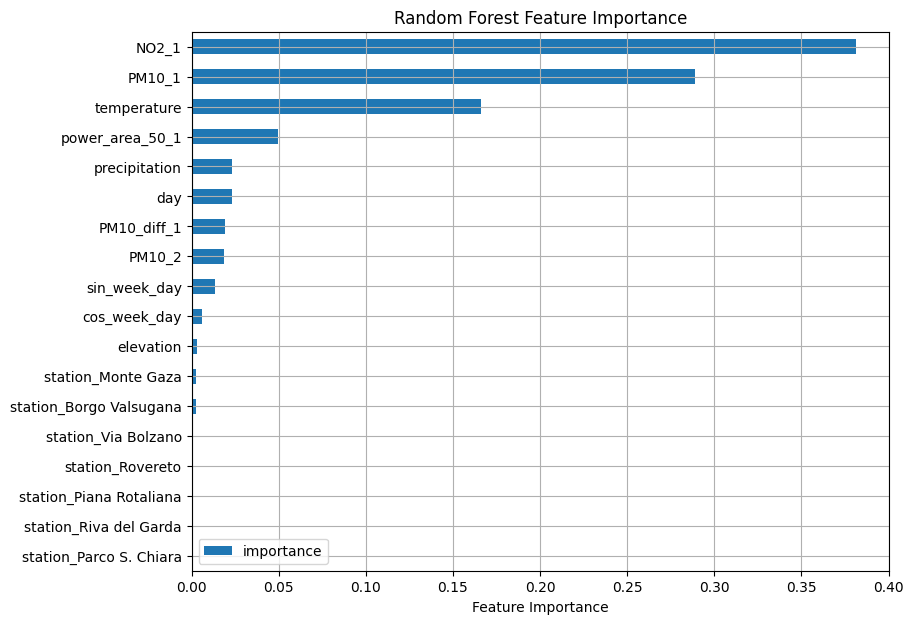

In [39]:
fs.display_importances(best_rfr_PM10_d, feature_cols)

Vediamo una distribuzione più variegata rispetto ai modelli orari trovati sopra e notiamo che la feature relativa alla concentrazione di PM10 del giorno precedente non è più la più importante poiché viene superata dalla concentrazione di NO2 del giorno precedente. In realtà ricordiamo che, come mostrato nell'EDA, i valori di questi inquinanti sono fortemente correlati e quindi ha senso che vengano usati entrambi; tuttavia, rimane importante notare come il modello prenda in considerazione molte altre feature. Questo ci suggerisce che il valore della concentrazione di un inquinante per un certo giorno sia molto meno correlato al suo valore il giorno prima rispetto a quanto sono correlate tra loro le concentrazioni di inquinanti riferite a due ore consecutive. Per questo motivo, il modello ha bisogno di fare affidamento su un ventaglio di feature più ampio e tiene conto anche di grandezze che ci sembrano intuitivamente meno importanti. È quindi possibile che stiamo sperimentando overfitting.

### Valutazione performance

In [40]:
full_PM10_d_tr = PM10_d_X_train.copy()
full_PM10_d_tr['actual'] = PM10_d_y_train
full_PM10_d_tr['prediction'] = best_rfr_PM10_d.predict(PM10_d_X_train)

full_PM10_d_te = PM10_d_X_test.copy()
full_PM10_d_te['actual'] = PM10_d_y_test
full_PM10_d_te['prediction'] = best_rfr_PM10_d.predict(PM10_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM10_d_tr['actual'], full_PM10_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM10_d_te['actual'], full_PM10_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          26.78347861622361
Root Mean Squared Error (RMSE):    5.175275704368185
Mean Absolute Error (MAE):         3.8707280825218744
Coefficient of Determination (R2): 0.883018591219585
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          205.86594530231432
Root Mean Squared Error (RMSE):    14.348029317725635
Mean Absolute Error (MAE):         9.766706539539978
Coefficient of Determination (R2): 0.5598946221499137


Vediamo che il modello funziona decisamente peggio rispetto a prima sotto tutti i punti di vista. Questo è potenzialmente legato ad un problema di overfitting ma riteniamo che, in realtà, sia dovuto ad altre caratteristiche del nostro dataset. La ridotta quantità di dati e la marcata differenza nella distribuzione dei dati tra train e test sono entrambi fattori che determinano quasi inevitabilmente una perdita di accuratezza per il nostro modello.

### Grafici previsioni

In questo caso, avendo molti meno dati, scegliamo di rappresentare i singoli punti in modo da poter confrontare accuratamente dati e previsioni.

In [41]:
# aggiungiamo il tempo
full_PM10_d_tr['time'] = full_PM10_d_tr['day']
full_PM10_d_te['time'] = full_PM10_d_te['day']

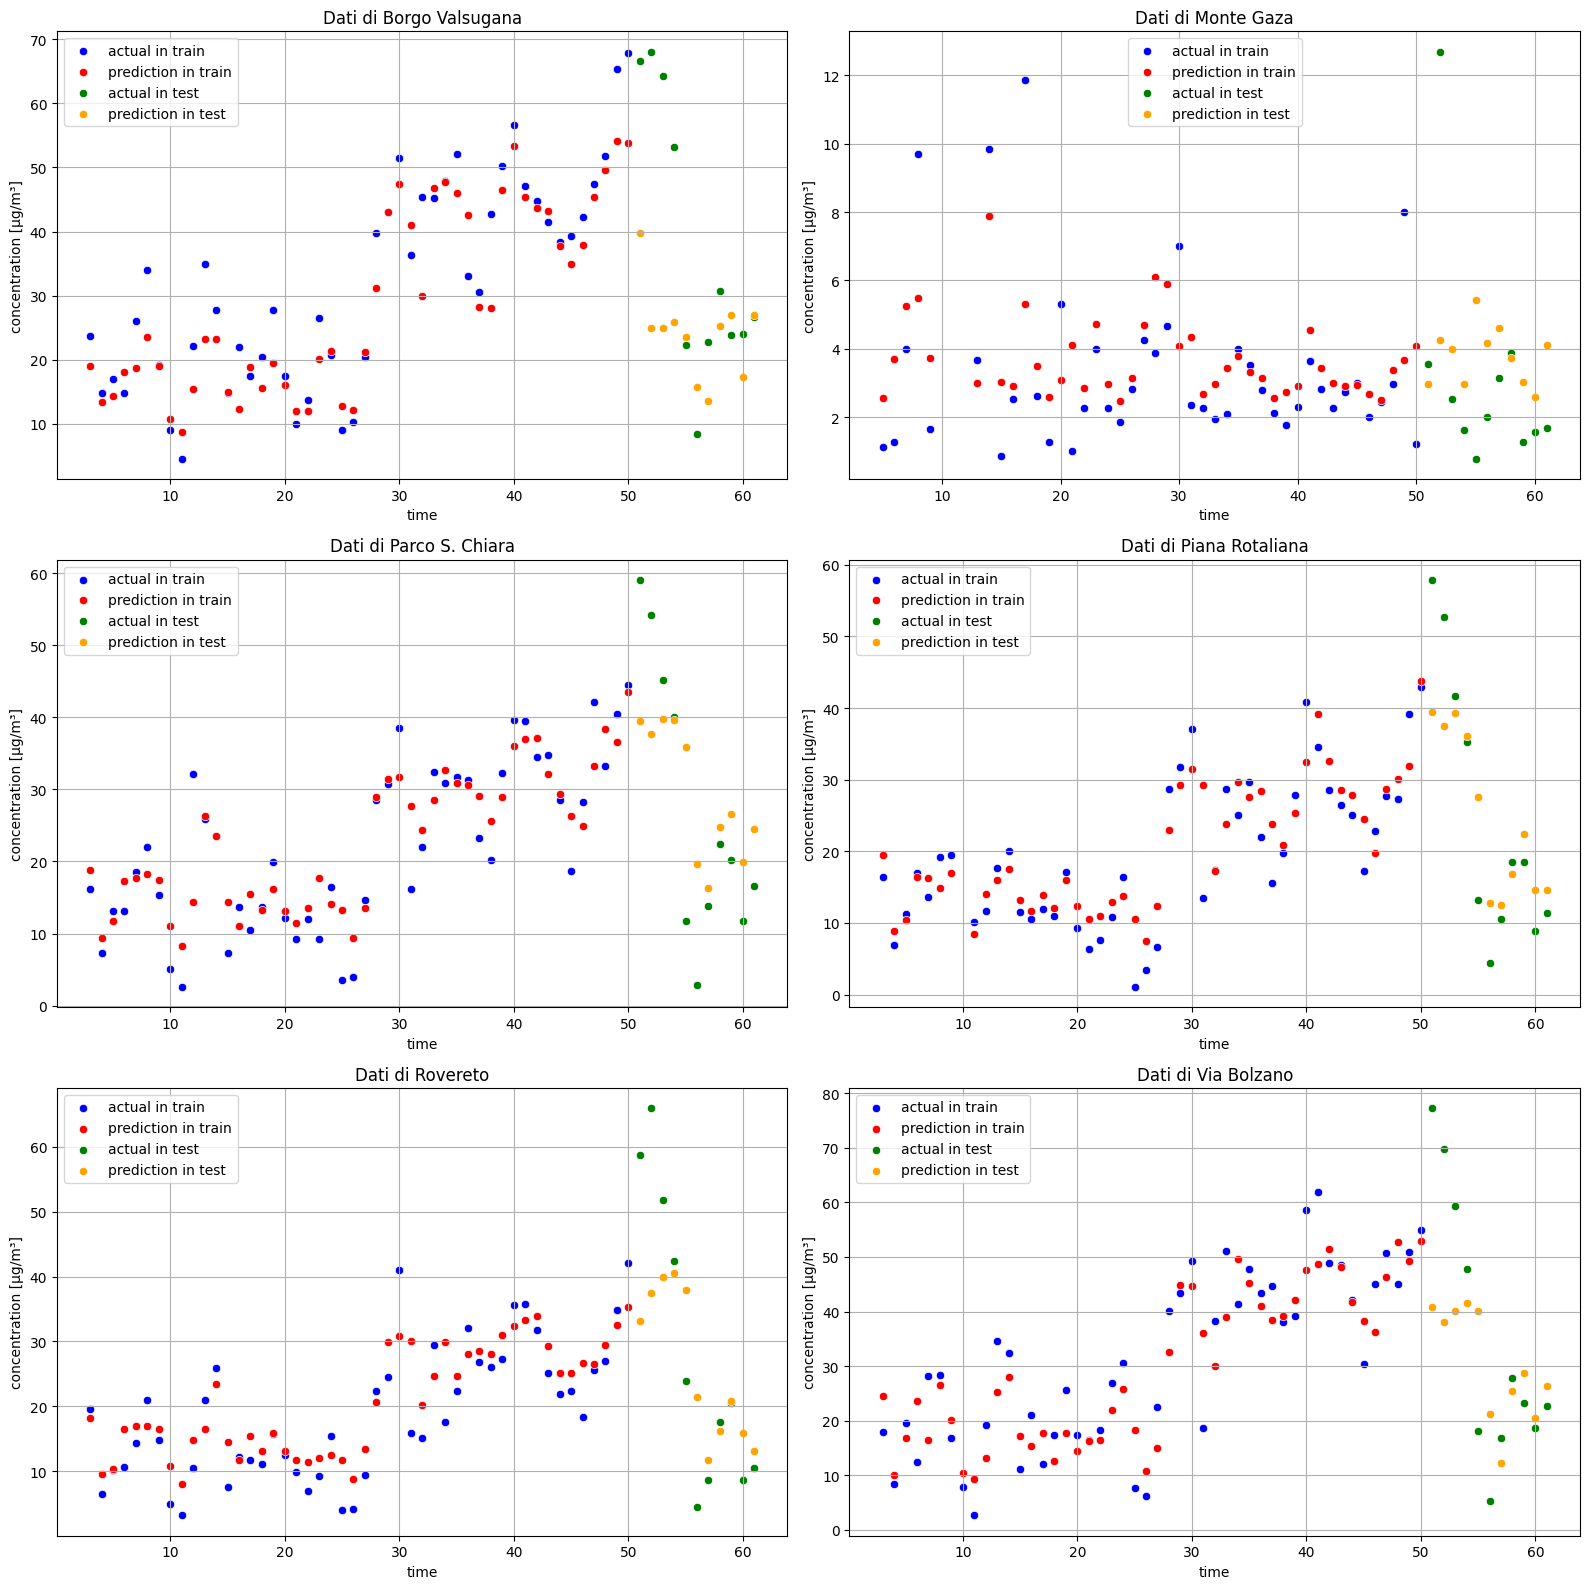

In [42]:
fs.plot_prediction_points(full_PM10_d_tr, full_PM10_d_te)

Vediamo che il modello ha prestazioni decenti nell'insieme di allenamento, almeno per la maggior parte delle stazioni, ma in test performa decisamente peggio, soprattutto in corrispondenza al grande picco di inquinanti dovuto al periodo natalizio. Come spiegato sopra, il modello si interfaccia con dati di questa magnitudo solo in test e quindi non ha basi per poterli prevedere accuratamente. Questo problema non è risolvibile senza incrementare il numero di dati e, perciò, per il momento dobbiamo accontentarci dei risultati poco incoraggianti. In seguito ripeteremo l'allenamento con metodo XGBoost per verificare se un modello più sofisticato è in grado di migliorare la performance del modello in test.

## PM2.5

In [43]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM25_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')
day_PM25_df.dropna(inplace=True)

In [44]:
day_PM25_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM2.5_1,PM2.5_2,PM2.5_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,0,0,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,24.764706,11.391304,13.373402,21.086957,18.197335,15.739130
1,1,0,0,0,0,0,0,410,4,1.000000,0.000000,10.796739,0.126087,15.739130,24.764706,-9.025575,18.826087,17.478475,8.347826
2,1,0,0,0,0,0,0,410,5,0.623490,0.781831,7.609783,0.028261,8.347826,15.739130,-7.391304,26.739130,37.200400,11.565217
3,1,0,0,0,0,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,11.565217,8.347826,3.217391,25.913043,37.421266,8.260870
4,1,0,0,0,0,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,8.260870,11.565217,-3.304348,26.956522,35.957377,16.478261


### Modello

In [45]:
rfr_PM25_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [46]:
# splittiamo il dataset
feature_cols = day_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_d_X_train, PM25_d_X_test, PM25_d_y_train, PM25_d_y_test = fs.get_train_test(day_PM25_df, 0.8, feature_cols)

### Allenamento modello

In [47]:
# training
rfr_PM25_d.fit(PM25_d_X_train, PM25_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [48]:
print('Best score:')
print(rfr_PM25_d.best_score_)
# miglior modello
best_rfr_PM25_d = rfr_PM25_d.best_estimator_

Best score:
-7.998442459313816


### Studio importanza features

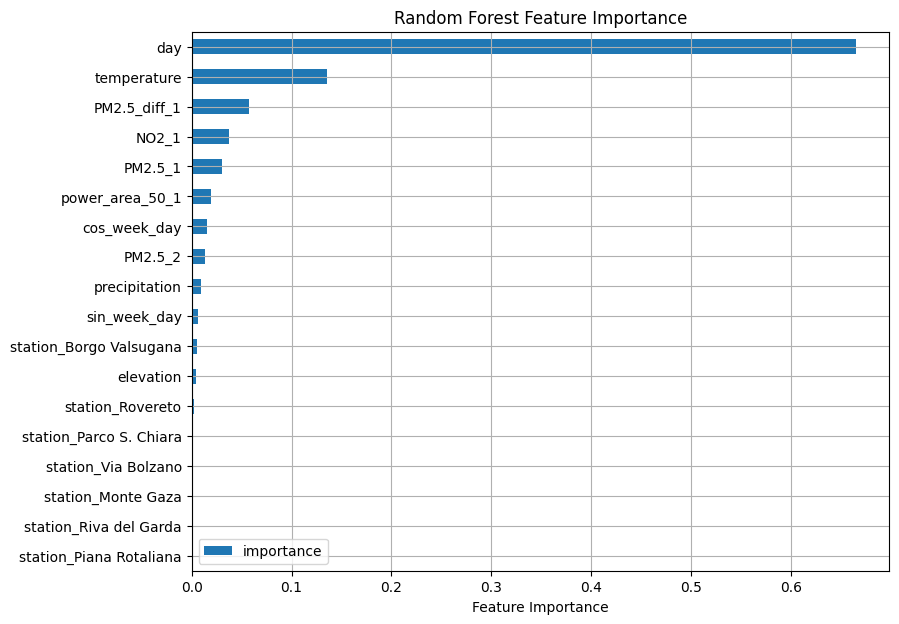

In [49]:
fs.display_importances(best_rfr_PM25_d, feature_cols)

Notiamo che rispetto a prima il modello usa una grande varietà di feature e che le prime sono poco intuitivamente collegate al valore di PM2.5 nell'aria. Questo è leggermente preoccupante poiché induce il dubbio che il modello stia essenzialmente imparando rumore.

### Valutazione performance

In [50]:
full_PM25_d_tr = PM25_d_X_train.copy()
full_PM25_d_tr['actual'] = PM25_d_y_train
full_PM25_d_tr['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_train)

full_PM25_d_te = PM25_d_X_test.copy()
full_PM25_d_te['actual'] = PM25_d_y_test
full_PM25_d_te['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_d_tr['actual'], full_PM25_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_d_te['actual'], full_PM25_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          11.732627310021725
Root Mean Squared Error (RMSE):    3.4252922955598586
Mean Absolute Error (MAE):         2.6632533667189415
Coefficient of Determination (R2): 0.8711971148817734
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          222.30887256016985
Root Mean Squared Error (RMSE):    14.910025907427855
Mean Absolute Error (MAE):         12.698716496129567
Coefficient of Determination (R2): 0.15213403384257695


Notiamo un importantissimo peggioramento del modello nell'interfacciarsi con dati nuovi, questo porta a pensare che stiamo quasi sicuramente commettendo overfitting. Anche se non riportato qui, abbiamo provato a rimuovere dall'allenamento le feature più importanti ('day' e 'temperature') e, sebbene la performance del modello migliori leggermente, rimane presente il drastico calo di prestazioni del modello in test. Probabilmente con questi dat non è possibile prevedere accuratamente il comportamento della qualità dell'aria, almeno non con RandomForestRegressor.

### Grafici previsioni

In [51]:
# aggiungiamo il tempo
full_PM25_d_tr['time'] = full_PM25_d_tr['day']
full_PM25_d_te['time'] = full_PM25_d_te['day']

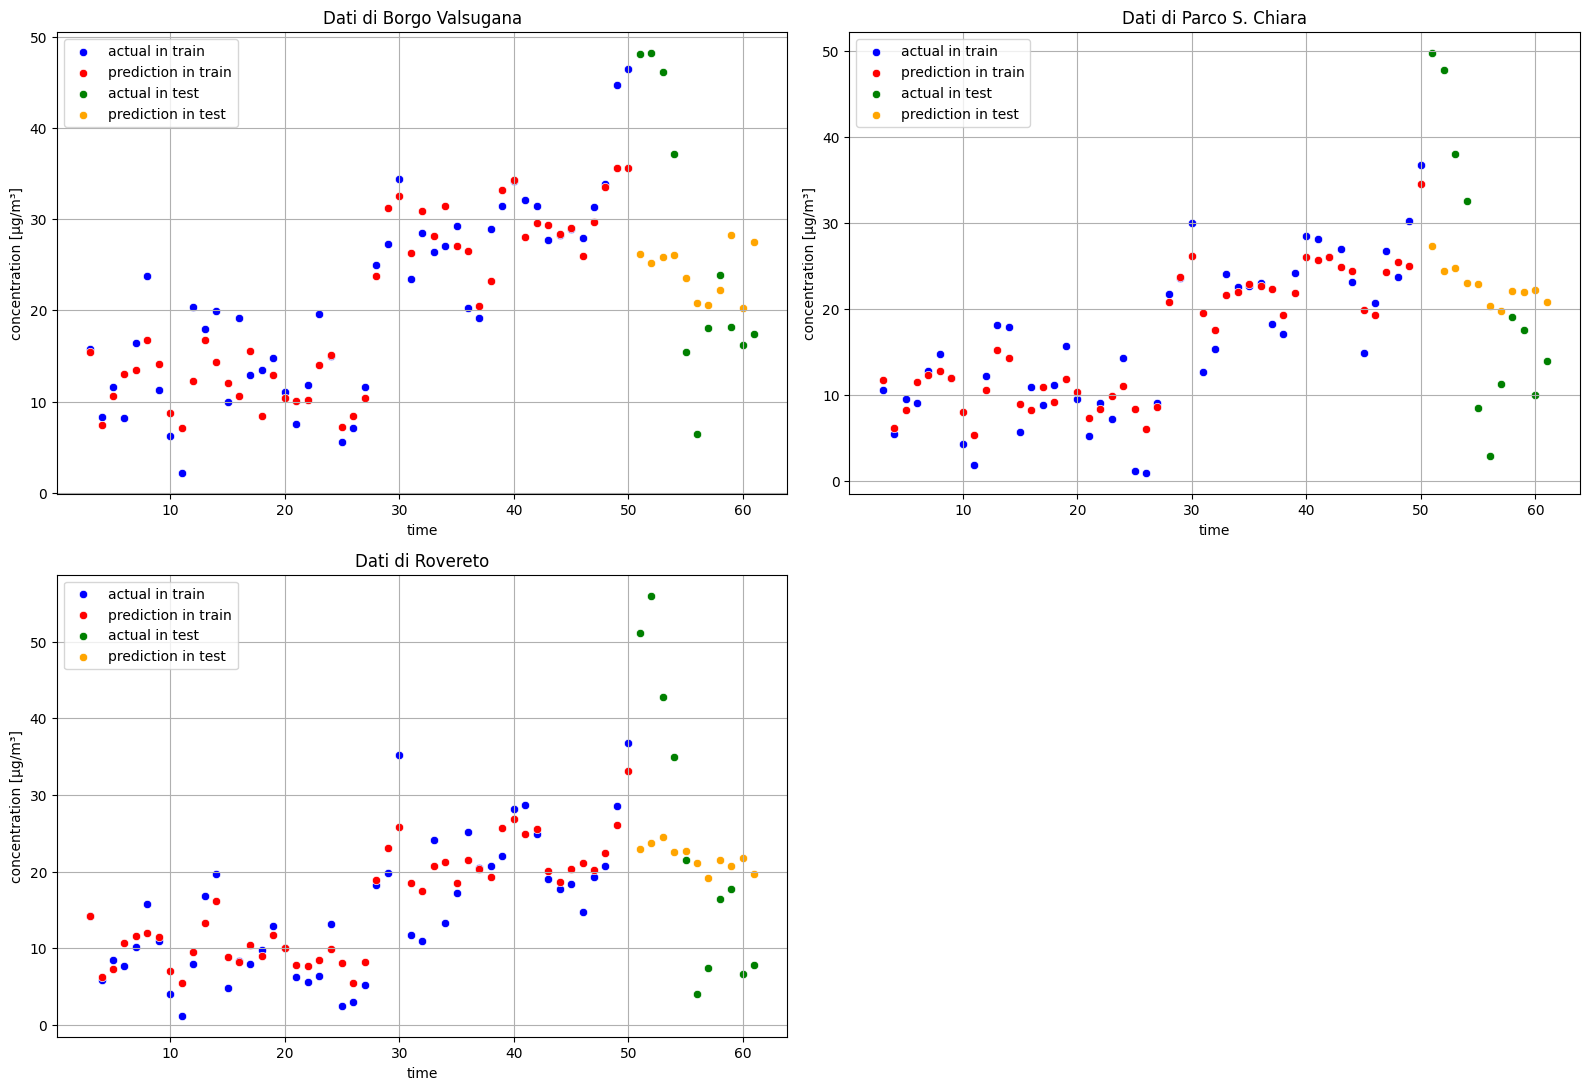

In [52]:
fs.plot_prediction_points(full_PM25_d_tr, full_PM25_d_te)

I grafici confermano la bassa qualità del modello in test, mostrando come il modello non sia in grado di prevedere la rapidissima decrescita della concentrazione di PM2.5. Le previsioni del modello in test rimangono essenzialmente costanti invece che seguire l'andamento dei dati. Questo è un problema difficile da risolvere purtroppo poiché abbiamo a disposizione pochi dati e le popolazioni intrain e test sono molto differenti tra loro.

## Ozono

In [53]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')
day_O3_df.dropna(inplace=True)

### Modello

In [54]:
rfr_O3_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [55]:
# splittiamo il dataset
feature_cols = day_O3_df.columns.difference(['target'])

# creiamo train e test
O3_d_X_train, O3_d_X_test, O3_d_y_train, O3_d_y_test = fs.get_train_test(day_O3_df, 0.8, feature_cols)

### Allenamento modello

In [56]:
# training
rfr_O3_d.fit(O3_d_X_train, O3_d_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=58327419), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5],
                         'max_features': [1.0], 'min_samples_leaf': [5],
                         'min_samples_split': [2], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [57]:
print('Best score:')
print(rfr_O3_d.best_score_)
# miglior modello
best_rfr_O3_d = rfr_O3_d.best_estimator_

Best score:
-20.25583527729727


### Studio importanza features

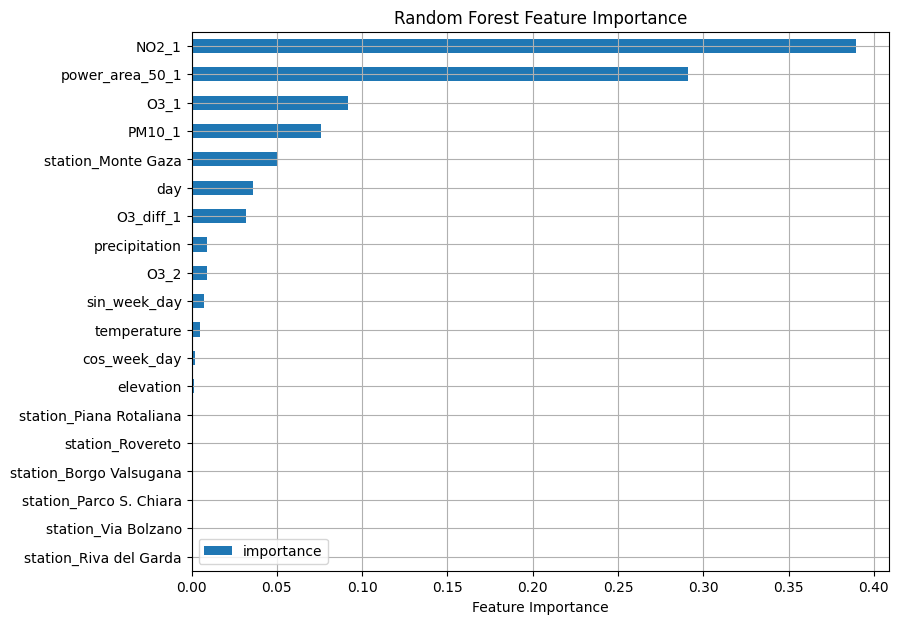

In [58]:
fs.display_importances(best_rfr_O3_d, feature_cols)

Come prima, le feature più rilevanti non sono quelle più legate da un punto di vista logico e fisico al target.

### Valutazione performance

In [59]:
full_O3_d_tr = O3_d_X_train.copy()
full_O3_d_tr['actual'] = O3_d_y_train
full_O3_d_tr['prediction'] = best_rfr_O3_d.predict(O3_d_X_train)

full_O3_d_te = O3_d_X_test.copy()
full_O3_d_te['actual'] = O3_d_y_test
full_O3_d_te['prediction'] = best_rfr_O3_d.predict(O3_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_d_tr['actual'], full_O3_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_d_te['actual'], full_O3_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          67.82842838744999
Root Mean Squared Error (RMSE):    8.23580162385241
Mean Absolute Error (MAE):         5.742747405081912
Coefficient of Determination (R2): 0.9106899903641068
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          151.69145401582674
Root Mean Squared Error (RMSE):    12.316308457318968
Mean Absolute Error (MAE):         10.233971728345816
Coefficient of Determination (R2): 0.806970361281824


Come sempre, si assiste ad una seria dimunuizione delle prestazioni del modello quando si interfaccia con dati nuovi ma non è un vero e proprio crollo come avvenuto per i PM2.5. Il modello sembra in realtà piuttosto buono, per quanto peggiore rispetto al modello orario (come sempre). Valutiamo qualitativamente le prestazioni del modello usando i grafici.

### Grafici previsioni

In [60]:
# aggiungiamo il tempo
full_O3_d_tr['time'] = full_O3_d_tr['day']
full_O3_d_te['time'] = full_O3_d_te['day']

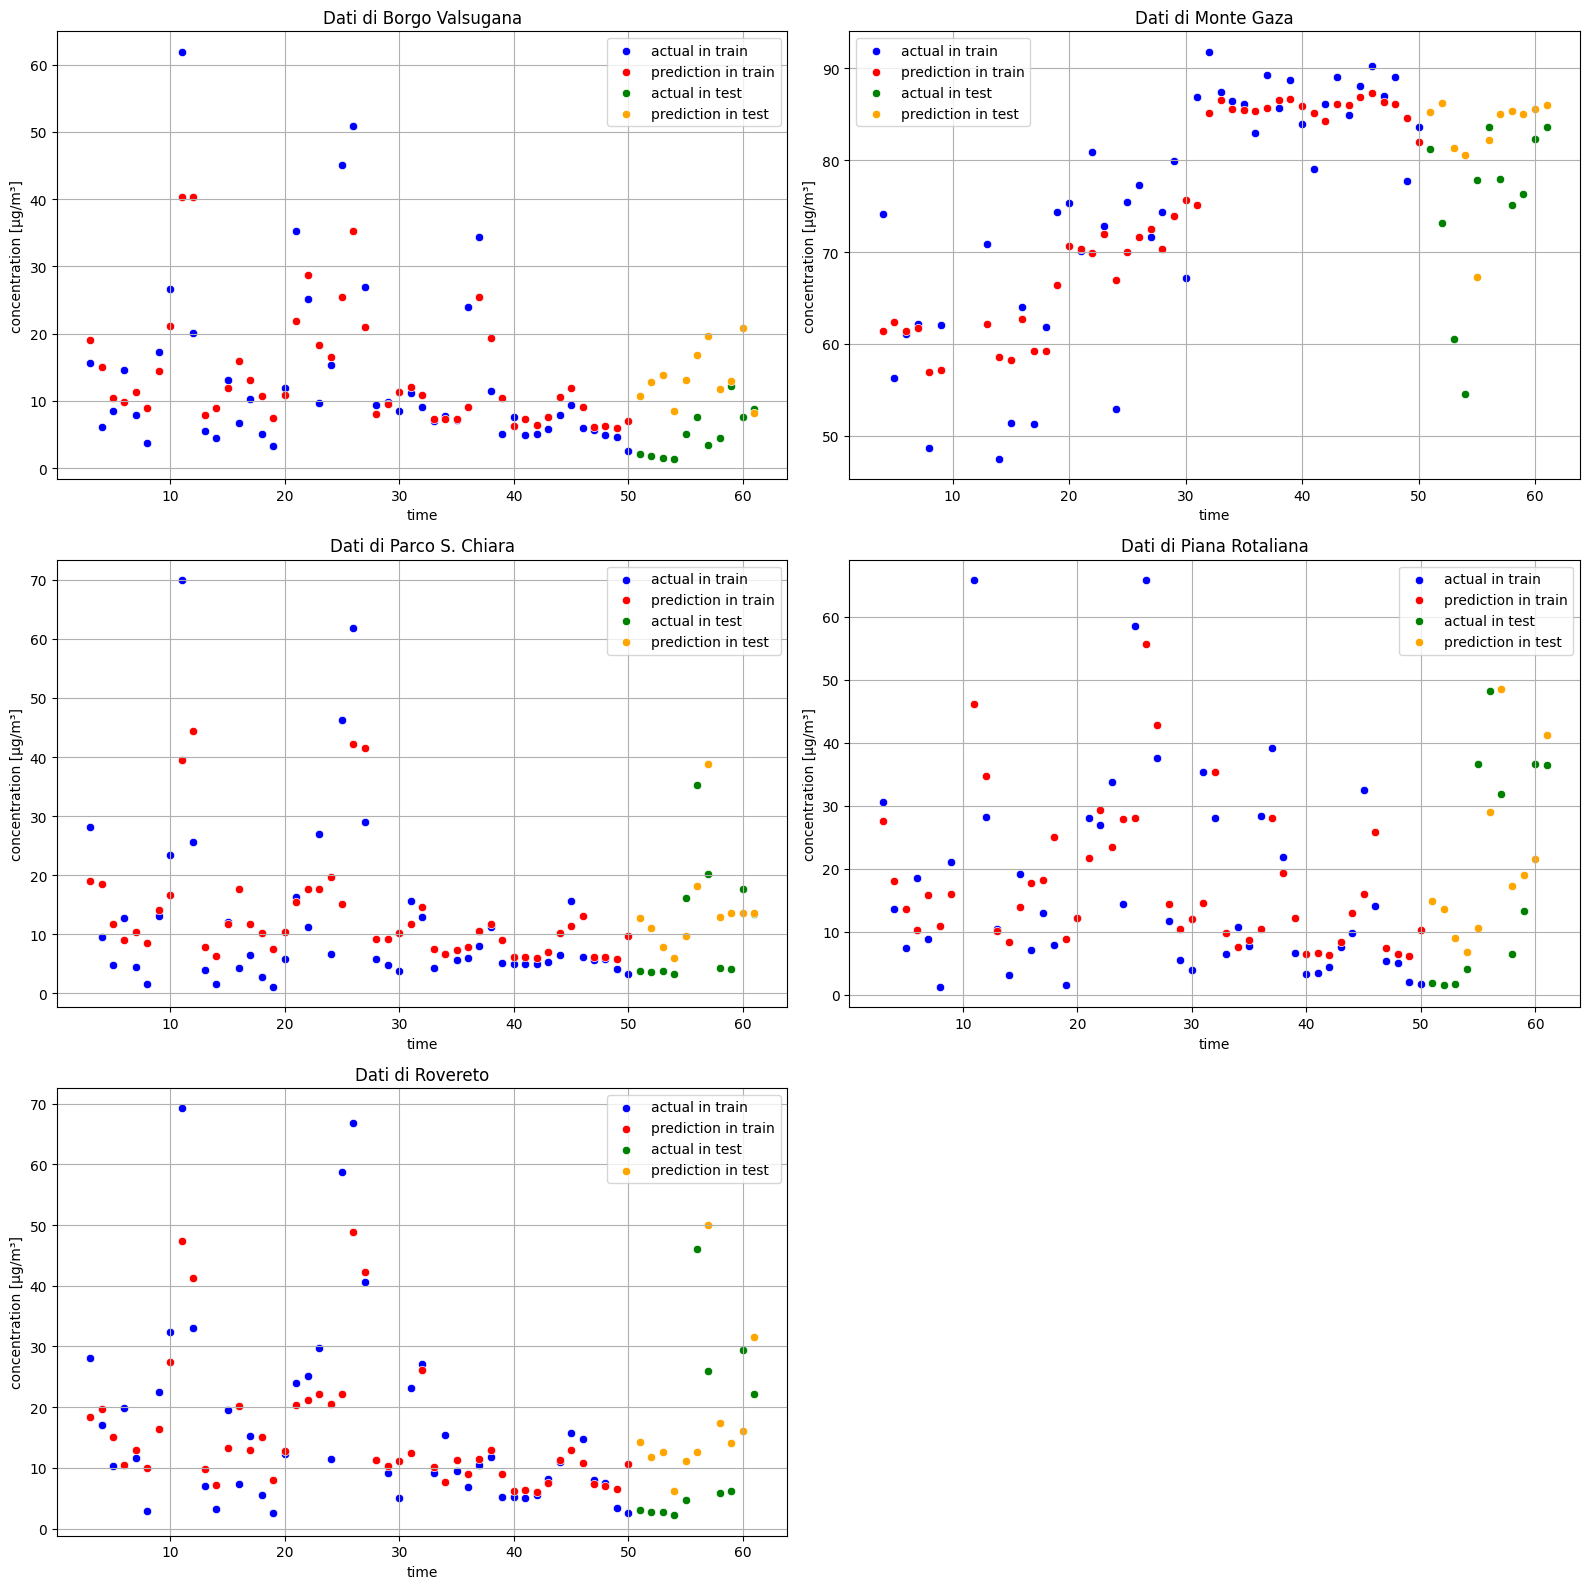

In [61]:
fs.plot_prediction_points(full_O3_d_tr, full_O3_d_te)

Le predizioni sono effettivamente più accurate rispetto a quanto avveniva pei PM10 e PM2.5. Tuttavia, questo sembra dovuto al fatto che il comportamento reale dell'ozono in test è meno patologico rispetto a quello di PM10 e PM2.5, e non tanto ad una effettiva bontà del modello. L'ozono, infatti, è sempre in controtendenza con gli altri inquinanti e, nel periodo in cui gli altri inquinanti mostrano un picco senza precedenti, l'ozono rimane costantemente basso ed è quindi difficile sbagliare le predizioni. Ad ogni modo, il modello sembra funzionare piuttosto bene e possiamo ritenerci soddisfatti.

# XGBoost - modelli giornalieri 2.0

Abbiamo visto che, nel caso di modelli a base giornaliera, i modelli costruiti con RandomForestRegressor lasciano un po' a desiderare. Proviamo quindi ad effettuare la regressione con metodo XGBoost, sperando di migliorare i risultati poco soddisfacenti di RandomForestClassifier. Mentre RandomForestClassifier costruisce una foresta di alberi volutamente indipendenti e scorrelati tra loro e media le loro predizioni, XGBoost crea una serie di alberi in cui ognuno cerca di correggere gli errori del precedente. Mentre RandomForestClassifier cerca di costruire alberi profondi e ramificati che funzionano bene anche individualmente, XGBoost crea alberi più semplici, che sono predittori singolarmente più deboli ma che funzionano bene come ensemble.

## PM10

In [62]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')
day_PM10_df.dropna(inplace=True)

### Modello

In questo caso, dato l'ingente numero di iperparametri considerati da XGBoost, controllare tutte le combinazioni richiederebbe molte ore, Per questo motivo, implementiamo una strategia del tipo RandomizedSearchCV, in modo da non cercare la combinazione migliore in assoluto ma otterne una comunque molto buona. Usando RandomizedSearchCV, possiamo introdurre un ultiore miglioramento: usare distribuzioni continue di parametri invece di valori discreti arbitrari.

In [63]:
tscv = TimeSeriesSplit(n_splits=5)

# distribuzioni degli iperparametri
param_dist = {'n_estimators': randint(150, 401),
                'max_depth': randint(2, 6),
                'learning_rate': uniform(0.02, 0.05),   # 0.02-0.07
                'min_child_weight': randint(5, 21),
                'gamma': uniform(0.0, 1.0),
                'subsample': uniform(0.6, 0.2),         # 0.6-0.8
                'colsample_bytree': uniform(0.6, 0.2),  # 0.6-0.8
                'reg_alpha': uniform(0.1, 2.0),
                'reg_lambda': uniform(5.0, 20.0)}

# ricerca randomizzata degli iperparametri
XGB_PM10_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [64]:
# splittiamo il dataset
feature_cols = day_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_d_X_train, PM10_d_X_test, PM10_d_y_train, PM10_d_y_test = fs.get_train_test(day_PM10_df, 0.8, feature_cols)

### Allenamento modello

In [65]:
# training
XGB_PM10_d.fit(PM10_d_X_train, PM10_d_y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7936392bb190>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936209ea170>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x793639474460>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936394eae90>},
                   random_state=58327419,
                   scoring='neg_root_mean_squared_error')

In [66]:
print('Best score:')
print(XGB_PM10_d.best_score_)
# miglior modello
best_XGB_PM10_d = XGB_PM10_d.best_estimator_

Best score:
-10.171650651980533


### Valutazione performance

In [67]:
full_PM10_d_tr = PM10_d_X_train.copy()
full_PM10_d_tr['actual'] = PM10_d_y_train
full_PM10_d_tr['prediction'] = best_XGB_PM10_d.predict(PM10_d_X_train)

full_PM10_d_te = PM10_d_X_test.copy()
full_PM10_d_te['actual'] = PM10_d_y_test
full_PM10_d_te['prediction'] = best_XGB_PM10_d.predict(PM10_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM10_d_tr['actual'], full_PM10_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM10_d_te['actual'], full_PM10_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          17.438302935231427
Root Mean Squared Error (RMSE):    4.175919411965636
Mean Absolute Error (MAE):         3.0670466049768583
Coefficient of Determination (R2): 0.9238352391288206
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          202.66572309901537
Root Mean Squared Error (RMSE):    14.236071196050382
Mean Absolute Error (MAE):         10.345714864717971
Coefficient of Determination (R2): 0.5667361373889633


Il modello sembra effettivamente migliore rispetto a prima. Rimane presente un drammatico peggioramento delle prestazioni del modello ma non riteniamo che questo sia principalmente dovuto all'overfitting poiché il valore dell'RMSE in test (14.2) è relativamente simile all'RMSE minimo ottenuto durante il RandomSearchCV (10.1). Quindi, anche tenendo conto di questo calo (che come visto è inevitabile poiché direttamente causato dai dati), il modello mostra prestazioni perlomeno decenti e, in ogni caso, migliori rispetto a prima.

### Grafici previsioni

In [68]:
# aggiungiamo il tempo
full_PM10_d_tr['time'] = full_PM10_d_tr['day']
full_PM10_d_te['time'] = full_PM10_d_te['day']

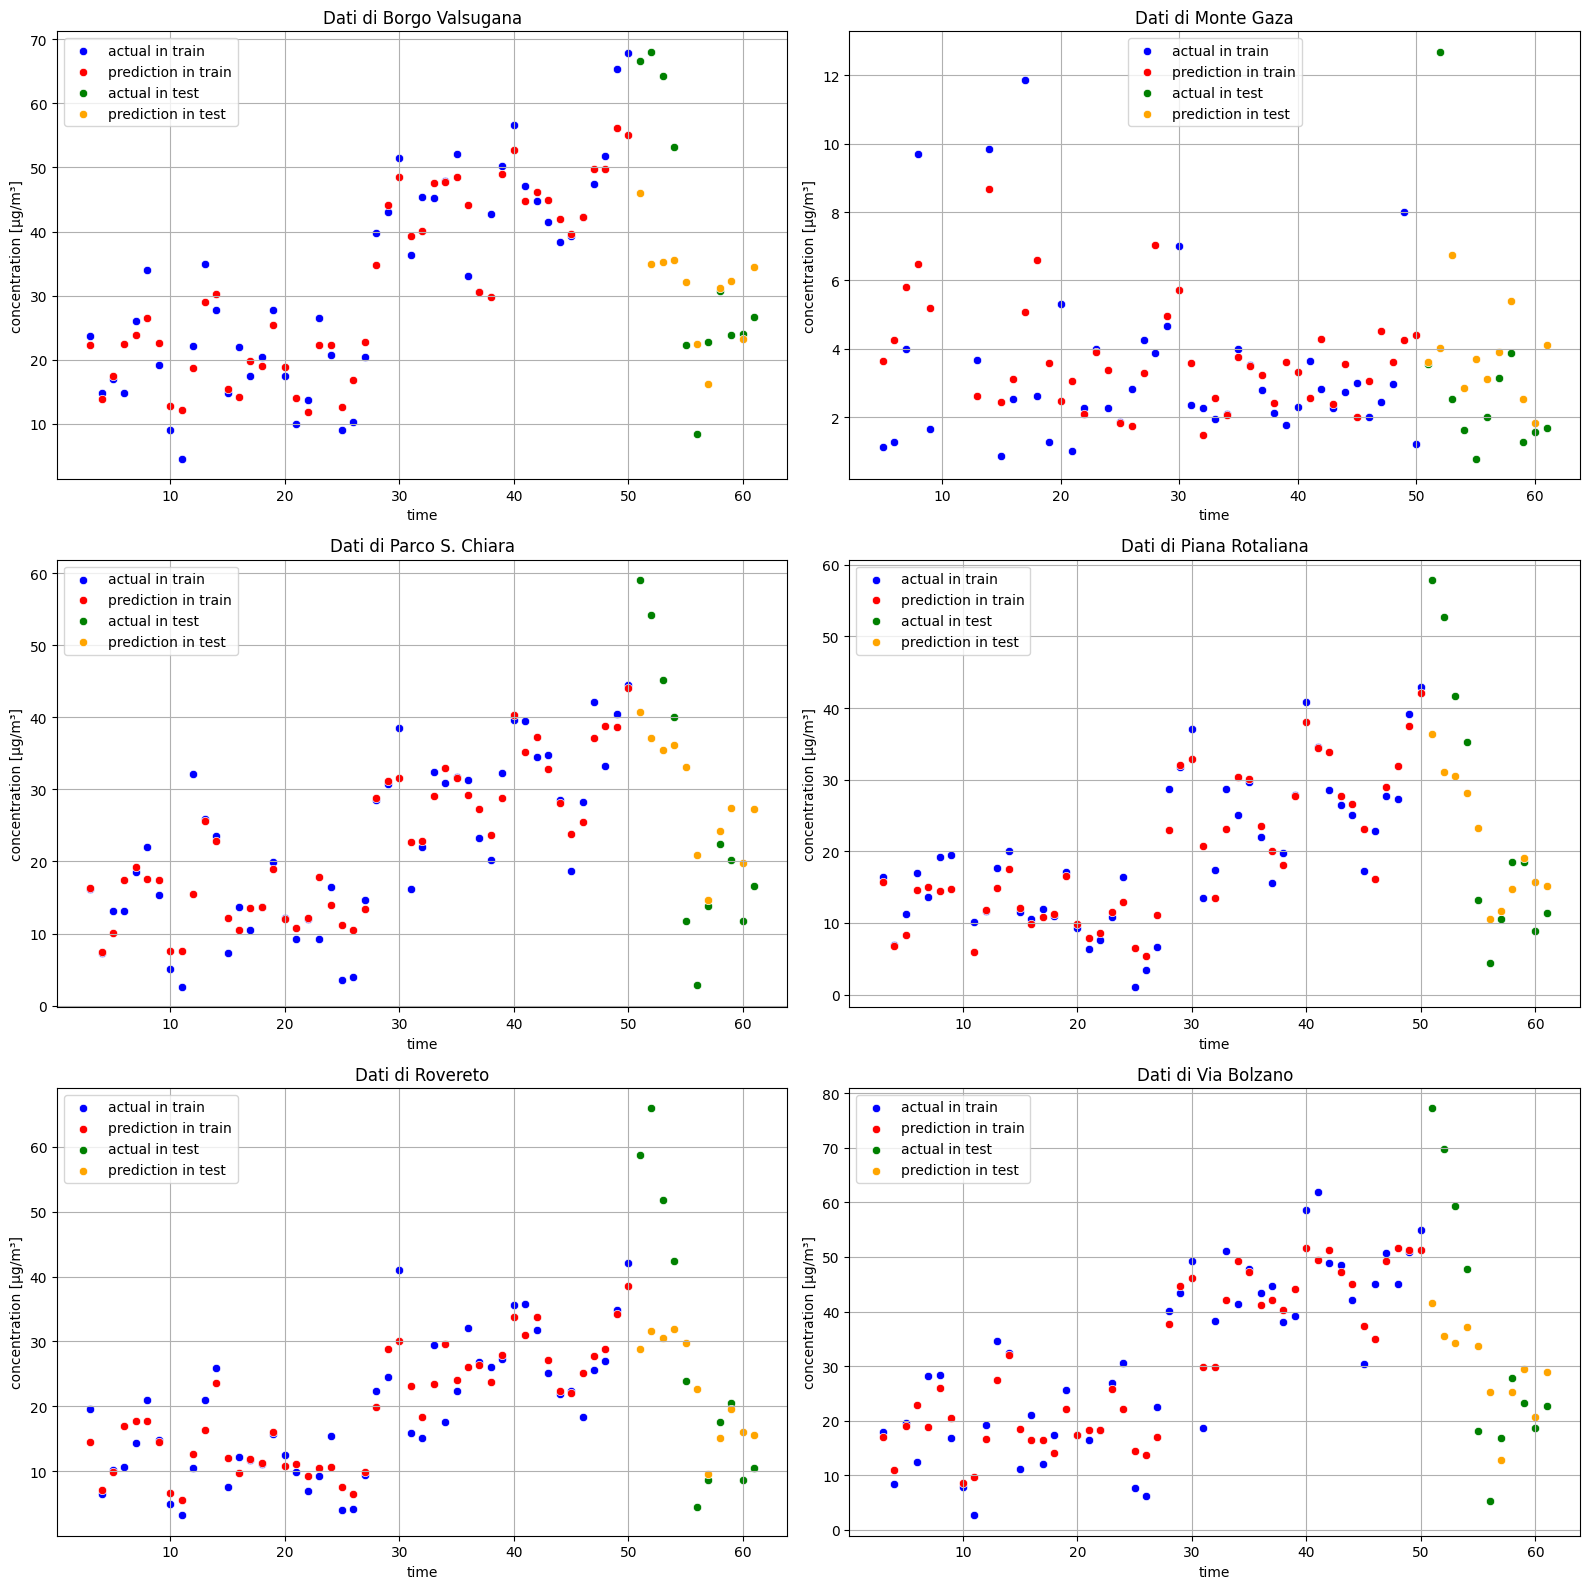

In [69]:
fs.plot_prediction_points(full_PM10_d_tr, full_PM10_d_te)

Vediamo che in train il modello funziona con incredibile accuratezza, tuttavia, su test peggiora significativamente, soprattutto in corrispondenza del picco, dove si interfaccia con dati molto diversi da quelli su cui è stato allenato.

## PM2.5

In [70]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM25_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')
day_PM25_df.dropna(inplace=True)

### Modello

In [71]:
# ricerca randomizzata degli iperparametri
XGB_PM25_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

In [72]:
# splittiamo il dataset
feature_cols = day_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_d_X_train, PM25_d_X_test, PM25_d_y_train, PM25_d_y_test = fs.get_train_test(day_PM25_df, 0.8, feature_cols)

### Allenamento modello

In [73]:
# training
XGB_PM25_d.fit(PM25_d_X_train, PM25_d_y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7936392bb190>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936209ea170>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x793639474460>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936394eae90>},
                   random_state=58327419,
                   scoring='neg_root_mean_squared_error')

In [74]:
print('Best score:')
print(XGB_PM25_d.best_score_)
# miglior modello
best_XGB_PM25_d = XGB_PM25_d.best_estimator_

Best score:
-7.336904320811175


### Valutazione performance

In [75]:
full_PM25_d_tr = PM25_d_X_train.copy()
full_PM25_d_tr['actual'] = PM25_d_y_train
full_PM25_d_tr['prediction'] = best_XGB_PM25_d.predict(PM25_d_X_train)

full_PM25_d_te = PM25_d_X_test.copy()
full_PM25_d_te['actual'] = PM25_d_y_test
full_PM25_d_te['prediction'] = best_XGB_PM25_d.predict(PM25_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_d_tr['actual'], full_PM25_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_d_te['actual'], full_PM25_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          3.5490925021591813
Root Mean Squared Error (RMSE):    1.8839035278270437
Mean Absolute Error (MAE):         1.396034692071523
Coefficient of Determination (R2): 0.961037426507267
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          198.29377741061927
Root Mean Squared Error (RMSE):    14.081682335950463
Mean Absolute Error (MAE):         11.765694914643433
Coefficient of Determination (R2): 0.24372543825593473


Vediamo che, purtroppo, anche usando XGBoost il modello migliora solo marginalmente rispetto a RandomForestRegressor. Sarebbe interessante riprovare questo esercizio a partire da un dataset molto più esteso (magari svariati anni) in modo da allenare meglio il modello e magari avere meno differenze tra train e test.

### Grafici previsioni

In [76]:
# aggiungiamo il tempo
full_PM25_d_tr['time'] = full_PM25_d_tr['day']
full_PM25_d_te['time'] = full_PM25_d_te['day']

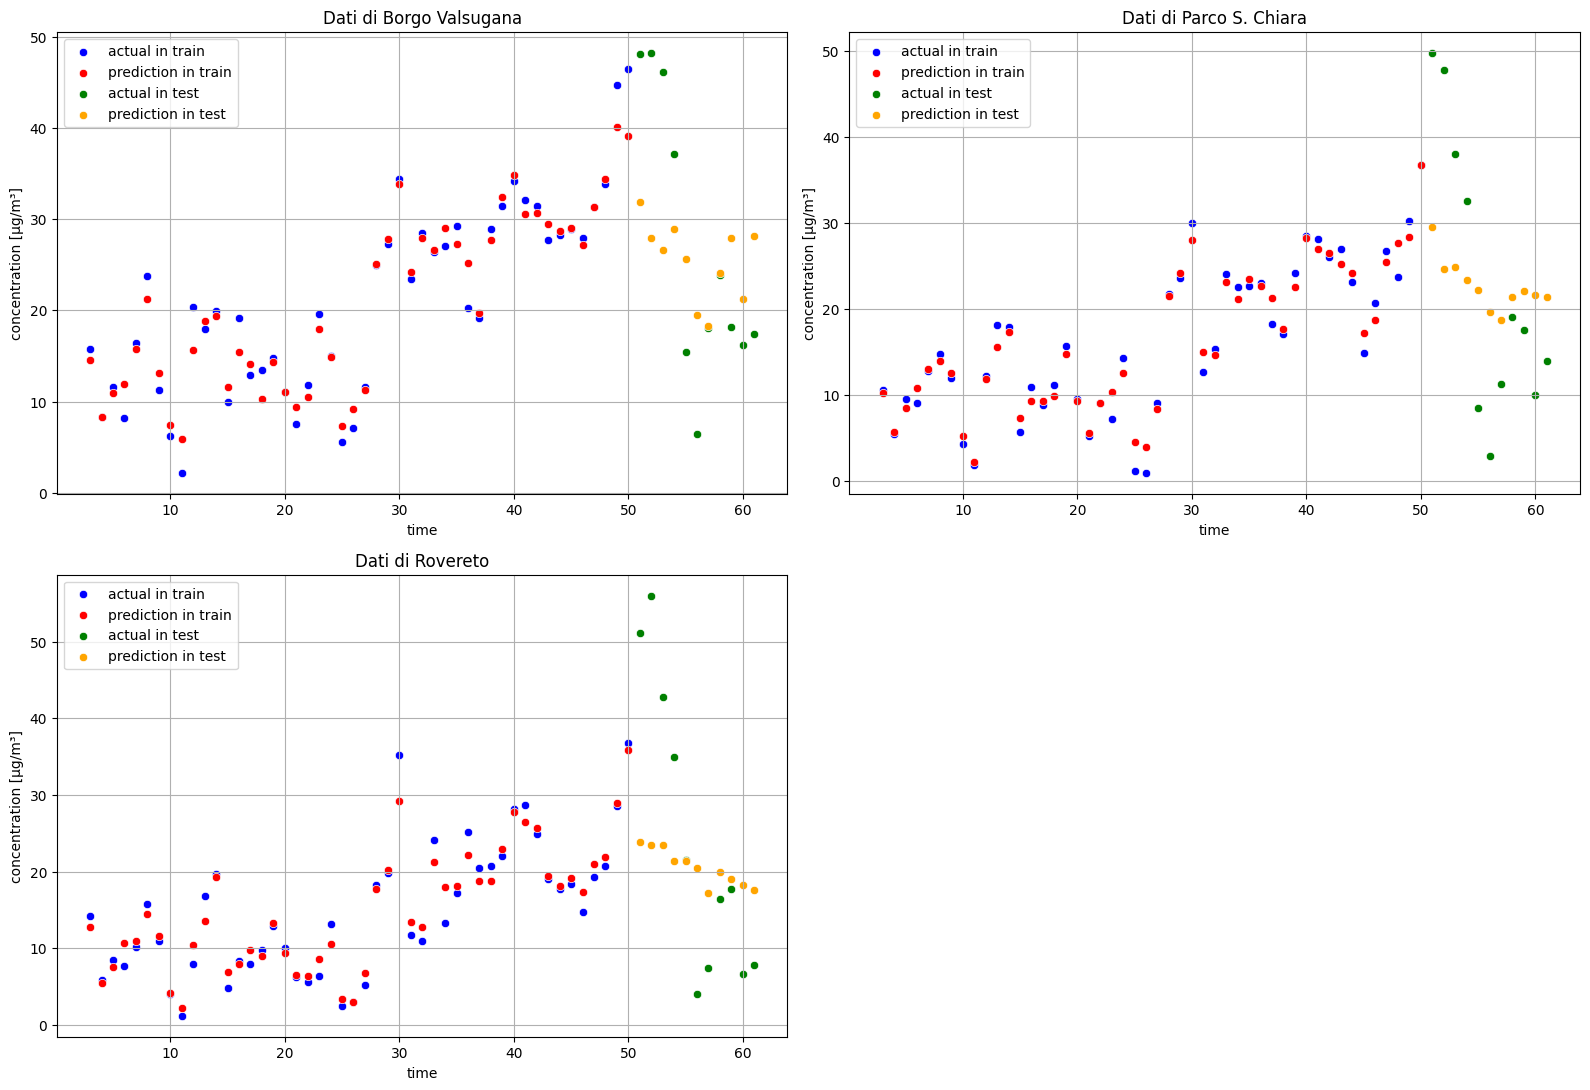

In [77]:
fs.plot_prediction_points(full_PM25_d_tr, full_PM25_d_te)

Vediamo che mentre in train il modello funziona molto molto bene, in test perde completamente la sua validità.

## Ozono

In [78]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')
day_O3_df.dropna(inplace=True)

### Modello

In [79]:
# ricerca randomizzata degli iperparametri
XGB_O3_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

In [80]:
# splittiamo il dataset
feature_cols = day_O3_df.columns.difference(['target'])

# creiamo train e test
O3_d_X_train, O3_d_X_test, O3_d_y_train, O3_d_y_test = fs.get_train_test(day_O3_df, 0.8, feature_cols)

### Allenamento modello

In [81]:
# training
XGB_O3_d.fit(O3_d_X_train, O3_d_y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7936392bb190>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936209ea170>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x793639474460>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7936394eae90>},
                   random_state=58327419,
                   scoring='neg_root_mean_squared_error')

In [82]:
print('Best score:')
print(XGB_O3_d.best_score_)
# miglior modello
best_XGB_O3_d = XGB_O3_d.best_estimator_

Best score:
-18.108707092084426


### Valutazione performance

In [83]:
full_O3_d_tr = O3_d_X_train.copy()
full_O3_d_tr['actual'] = O3_d_y_train
full_O3_d_tr['prediction'] = best_XGB_O3_d.predict(O3_d_X_train)

full_O3_d_te = O3_d_X_test.copy()
full_O3_d_te['actual'] = O3_d_y_test
full_O3_d_te['prediction'] = best_XGB_O3_d.predict(O3_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_d_tr['actual'], full_O3_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_d_te['actual'], full_O3_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          10.615509372450779
Root Mean Squared Error (RMSE):    3.2581450815534256
Mean Absolute Error (MAE):         2.377292942877341
Coefficient of Determination (R2): 0.9860225090440262
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          158.31542304509418
Root Mean Squared Error (RMSE):    12.582345689301903
Mean Absolute Error (MAE):         10.705667197886058
Coefficient of Determination (R2): 0.7985412618516974


Vediamo che il modello rimane in realtà effettivamente invariato rispetto a quanto ottenuto con RandomForestRegressor.

### Grafici previsioni

In [84]:
# aggiungiamo il tempo
full_O3_d_tr['time'] = full_O3_d_tr['day']
full_O3_d_te['time'] = full_O3_d_te['day']

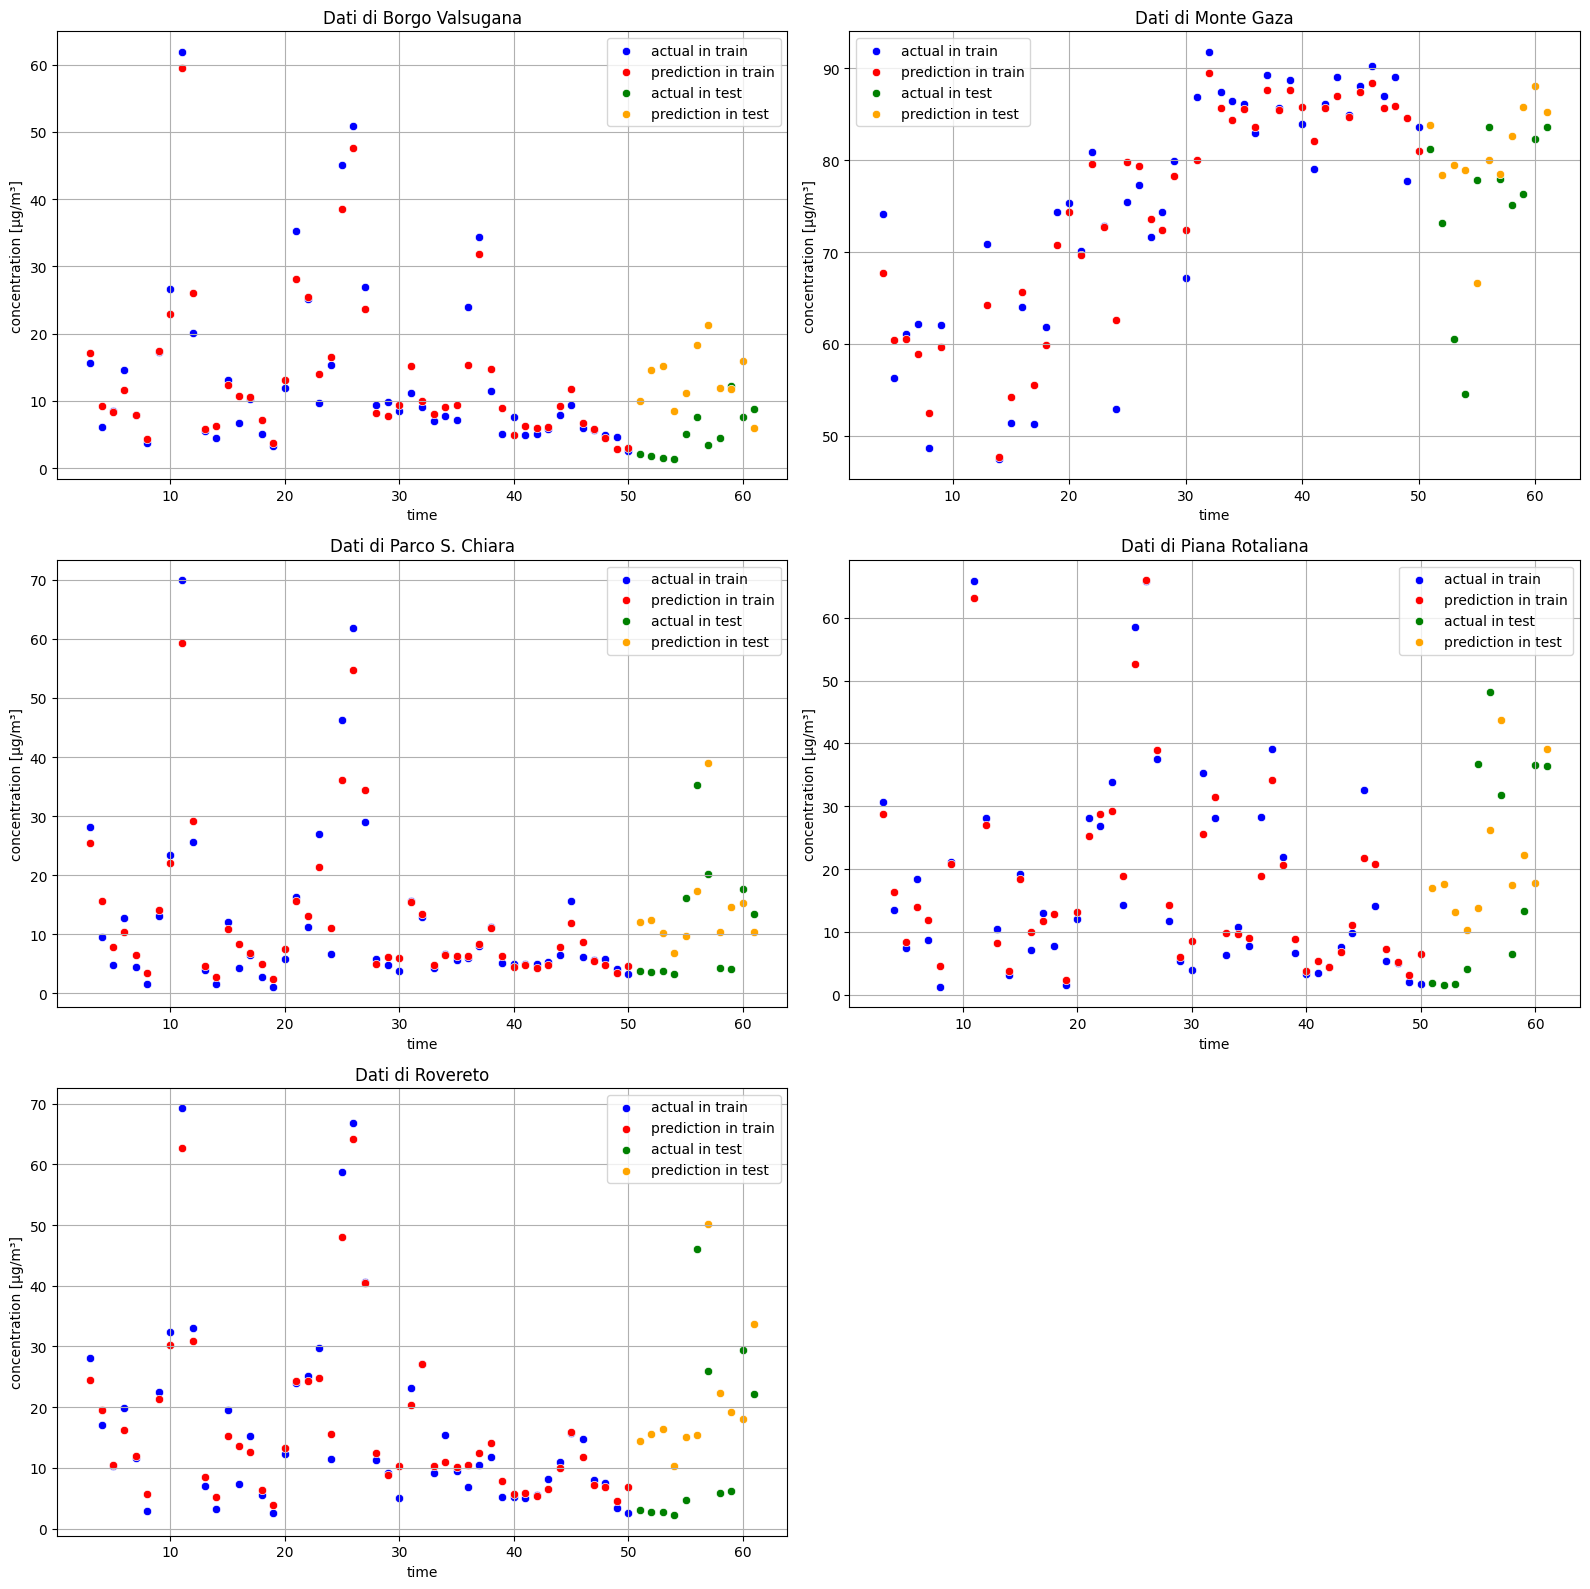

In [85]:
fs.plot_prediction_points(full_O3_d_tr, full_O3_d_te)

Vediamo che il modello è molto poco accurato in test e il buon valore dei parametri è dovuto più al fatto che i dati di test sono molto omogenei che all'effettiva qualità del modello.

# Conclusioni

Riteniamo l'allenamento dei modelli orari un successo visto che i modelli si comportano piuttosto bene su test e producono predizioni ragionevolmente vicine alla realtà. D'altro canto, i modelli giornalieri sono poco efficaci e, a causa della carenza di dati, non siamo in grado di risolvere la patologie dei nostri insiemi.